Assignment 15: Loan Default Prediction

This project focuses on predicting loan default risk using machine learning techniques. The goal is to build a model that can identify whether a borrower is likely to default based on financial and personal attributes such as income, debt, and employment history.

A Random Forest classifier is used for prediction, along with data preprocessing, feature engineering, and model evaluation. In addition, the project includes model explainability using SHAP (SHapley Additive exPlanations) and fairness analysis across age groups to evaluate potential bias in predictions.

The purpose of this work is not only to build an accurate model but also to consider ethical aspects such as fairness, transparency, and responsible AI use in financial decision-making.

- GitHub Repository: https://colab.research.google.com/drive/1gBR-5U1u3hee0RE0SDaC3D3vZOzVE00A?usp=sharing
- Google Colab Notebook: https://github.com/alyssaiapalucci4/assignment-15-loan-default-ml

In [70]:
# IMPORTS

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [71]:
# LOAD DATA

df = pd.read_csv("bank-loan.csv")
df.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


In [72]:
# CLEAN TARGET
df = df.dropna(subset=["default"])

In [73]:
# BASIC CHECKS
df.info()
df.describe()
df["default"].value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 0 to 699
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       700 non-null    int64  
 1   ed        700 non-null    int64  
 2   employ    700 non-null    int64  
 3   address   700 non-null    int64  
 4   income    700 non-null    int64  
 5   debtinc   700 non-null    float64
 6   creddebt  700 non-null    float64
 7   othdebt   700 non-null    float64
 8   default   700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 54.7 KB


,count
default,
0.0,517
1.0,183


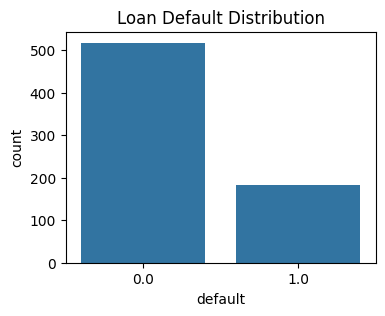

In [148]:
# EDA

# Loan Default Distribution
plt.figure(figsize=(4,3))
sns.countplot(x="default", data=df)
plt.title("Loan Default Distribution")
plt.show()

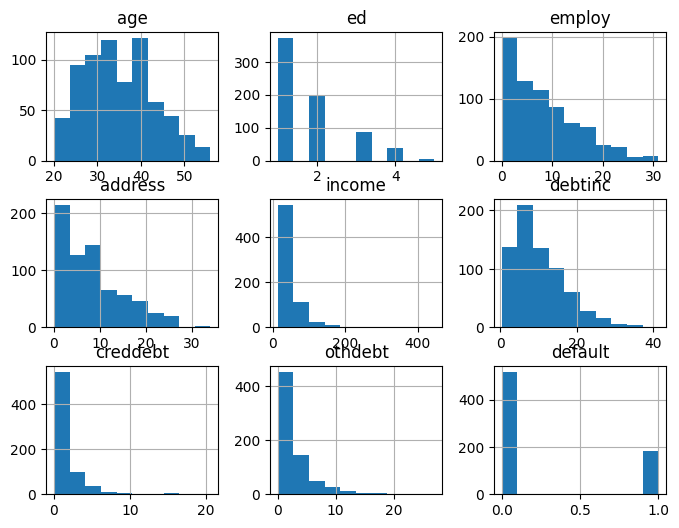

In [149]:
df.hist(figsize=(8,6))
plt.show()

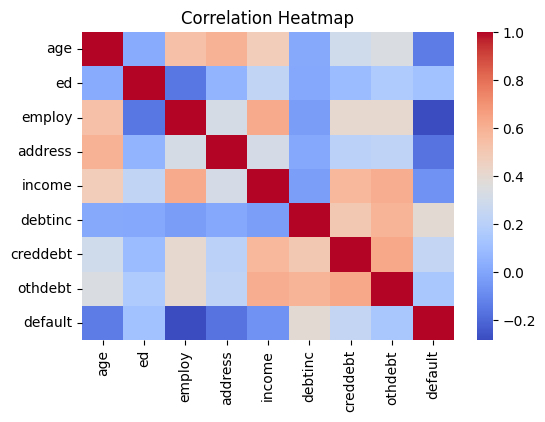

In [150]:
#Correlation Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [77]:
# FEATURE ENGINEERING

df["total_debt"] = df["creddebt"] + df["othdebt"]
df["debt_to_income"] = df["debtinc"] / 100
df["credit_pressure"] = df["creddebt"] / (df["income"] + 1)
df["other_debt_ratio"] = df["othdebt"] / (df["income"] + 1)

In [78]:
# SPLIT FEATURES + TARGET

X = df.drop("default", axis=1)
y = df["default"]

In [79]:
# SCALE FEATURES

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [80]:
# TRAIN / TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [81]:
# TRAIN RANDOM FOREST

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [82]:
# PREDICTIONS

y_pred = model.predict(X_test)

In [83]:
# EVALUATION

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8285714285714286
[[94  9]
 [15 22]]
              precision    recall  f1-score   support

         0.0       0.86      0.91      0.89       103
         1.0       0.71      0.59      0.65        37

    accuracy                           0.83       140
   macro avg       0.79      0.75      0.77       140
weighted avg       0.82      0.83      0.82       140



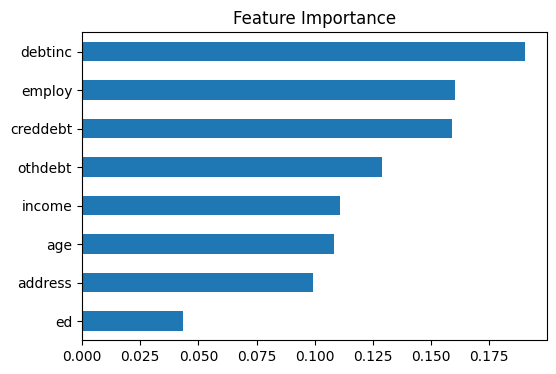

In [151]:
# FEATURE IMPORTANCE

importances = pd.Series(model.feature_importances_, index=X.columns)

importances.sort_values().plot(kind="barh", figsize=(6,4))
plt.title("Feature Importance")
plt.show()

TASK 4 — Step 1: CLEAN SETUP

In [128]:
# Imports
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

In [129]:
# Load + clean data
df = pd.read_csv("bank-loan.csv")

df = df.dropna(subset=["default"])

X = df.drop("default", axis=1)
y = df["default"]

In [130]:
# Scale data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [131]:
# Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [132]:
# Train model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

TASK 4 — STEP 2: SHAP EXPLAINABILITY

In [133]:
# Create SHAP explainer

import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

In [134]:
# Check output type

type(shap_values)

numpy.ndarray

In [139]:
# Prepare class 1 SHAP values

shap_values_class1 = shap_values

In [137]:
# Fix feature format

X_test_df = pd.DataFrame(X_test, columns=X.columns)

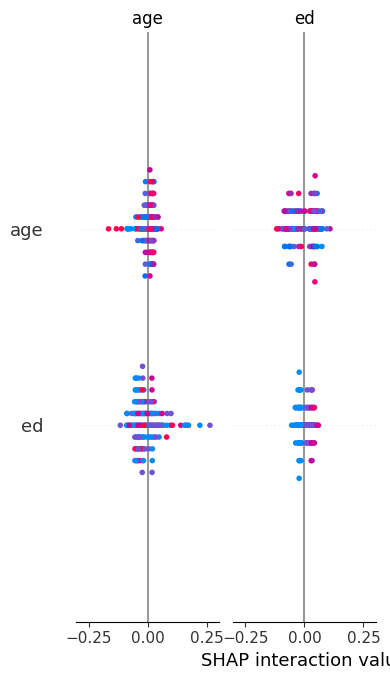

In [140]:
# GLOBAL EXPLANATION

shap.summary_plot(shap_values_class1, X_test_df)

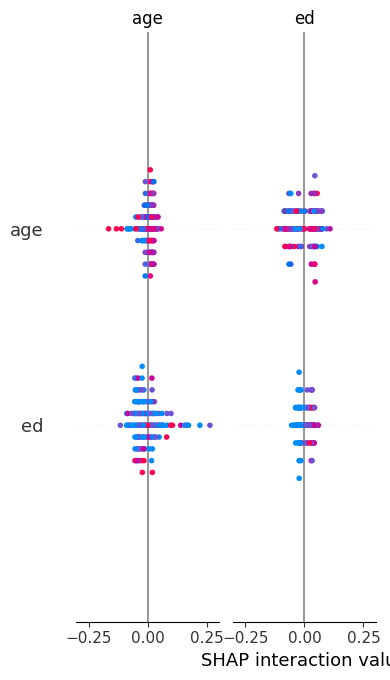

In [141]:
# FEATURE IMPORTANCE (BAR PLOT)
shap.summary_plot(
    shap_values_class1,
    X_test_df,
    plot_type="bar"
)

STEP 3 — FAIRNESS ANALYSIS

In [142]:
# Create fairness dataset
df_fair = df.copy()

In [143]:
# Create demographic groups (AGE)
df_fair["age_group"] = pd.cut(
    df_fair["age"],
    bins=[0, 25, 40, 60, 100],
    labels=["Young", "Adult", "Senior", "Elder"]
)

In [144]:
# Add predictions
df_fair["prediction"] = model.predict(X_scaled)

In [145]:
# FAIRNESS METRIC (ACTUAL DEFAULT RATE)
df_fair.groupby("age_group")["default"].mean()

/tmp/ipykernel_5222/2584444382.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_fair.groupby("age_group")["default"].mean()


,default
age_group,
Young,0.465116
Adult,0.243182
Senior,0.206897
Elder,NaN


In [146]:
# FAIRNESS METRIC (PREDICTED DEFAULT RATE)
df_fair.groupby("age_group")["prediction"].mean()

/tmp/ipykernel_5222/1445431992.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_fair.groupby("age_group")["prediction"].mean()


,prediction
age_group,
Young,0.476744
Adult,0.227273
Senior,0.195402
Elder,NaN


/tmp/ipykernel_5222/1009357509.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_fair.groupby("age_group")["prediction"].mean().plot(kind="bar")


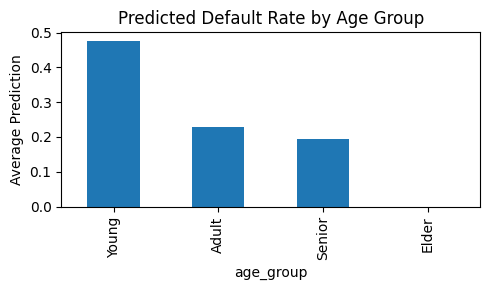

In [152]:
# VISUALIZATION
import matplotlib.pyplot as plt

plt.figure(figsize=(5,3))  # adjust size here

df_fair.groupby("age_group")["prediction"].mean().plot(kind="bar")

plt.title("Predicted Default Rate by Age Group")
plt.ylabel("Average Prediction")

plt.tight_layout()
plt.show()